Application de la méthode de pénalisation extérieure sur un réseau de neuronnes

phi(x, r) = F(x) + r*SOMME(j = 1 à p)(G(g_j(x)))
pour une valeur de r assez importante.

Ensuite, on cherche le min du NN en faisant une descente de gradient :
x_i+1 = x_i - lambda*grad(NN(x))

Exemple : phi(x, r = 100) = (1/3)*(x1 + 1)^3 + x2 + 100*((max(0, 1 - x1))² + (max(0, -x2))²)
                                                         
Pour la méthode de régression, on prendra une grille 1000x1000 sur [-2, 2]x[-2, 2]

Dans la méthode de descente de gradient, on prendra lambda = 10^(-2)

On prendra comme point de départ x0 = (1.5, 0.5)

In [1]:
# Définition des fonctions

import numpy as np

def F(x):
    return (1/3)*(x[0]**3) + x[1]

def phi(x, r):
    return F(x) + r*((max(0, 1 - x[0]))**2 + (max(0, -x[1]))**2)

In [2]:
# Construction des données

r = 100

N = 1000
X_train = np.zeros((N*N, 2))
d_x_y = np.array([[4/N, 4/N]])

y_train = np.zeros((N*N, 1))

count = 0
for i in range(N):
    for j in range(N):
        x = np.array([i * 4 / N - 2, j * 4 / N - 2])
        X_train[count, :] = x
        y_train[count] = phi(x, r)
        count += 1

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, Input, Model
import matplotlib.pyplot as plt

# Définition du réseau de neurones avec l'API Functional (Model)

inputs = Input(shape=(2,))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='mse')

# Entraînement du réseau
history = model.fit(X_train, y_train, epochs=20, batch_size=1024, verbose=1)

Epoch 1/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - loss: 57852.8633 
Epoch 2/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 3158.1567
Epoch 3/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 899.7652 
Epoch 4/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 478.0077
Epoch 5/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - loss: 186.7744
Epoch 6/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - loss: 40.0270
Epoch 7/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - loss: 15.7636
Epoch 8/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - loss: 10.3721
Epoch 9/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - loss: 7.5504
Epoch 10/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - loss: 5.6561
Epoch 11/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - loss: 4.5745
Epoch 12/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - loss: 3.8468
Epoch 13/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - loss: 3.3893
Epoch 14/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - loss: 3.0540
Epoch 15/20

In [4]:
# Descente de gradient pour trouver le minimum du réseau entraîné
lambda_ = 1e-2
x = tf.Variable([[1.5, 0.5]], dtype=tf.float32)
n_iter = 100

x_history = [x.numpy().copy()]
for i in range(n_iter):
    with tf.GradientTape() as tape:
        y_pred = model(x)
    grad = tape.gradient(y_pred, x)
    x.assign_sub(lambda_ * grad)
    x_history.append(x.numpy().copy())

x_history = np.array(x_history).reshape(-1, 2)

print("Point minimum trouvé :", x.numpy())
print("Valeur prédite par le NN :", model(x).numpy())

Point minimum trouvé : [[1.493757   0.33265352]]
Valeur prédite par le NN : [[1.948924]]


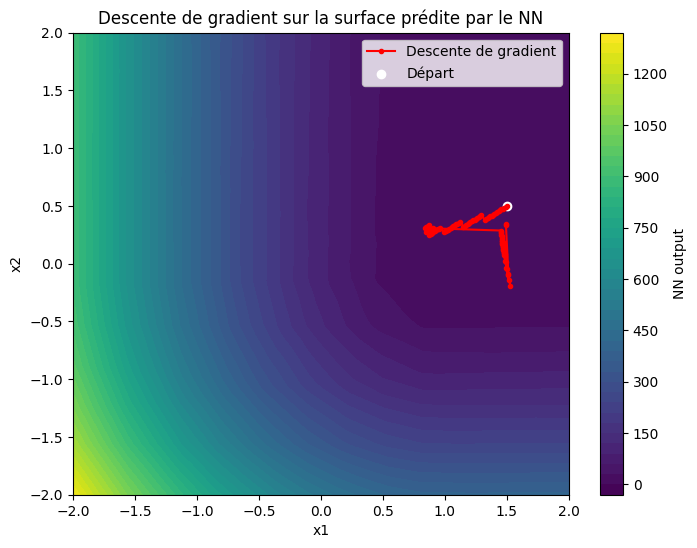

In [5]:
# Affichage de la trajectoire de la descente de gradient sur la surface prédite par le NN

xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
zz = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, zz, levels=50, cmap='viridis')
plt.colorbar(label='NN output')
plt.plot(x_history[:,0], x_history[:,1], 'r.-', label='Descente de gradient')
plt.scatter([1.5], [0.5], color='white', label='Départ')
plt.title("Descente de gradient sur la surface prédite par le NN")
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [6]:
x0 = np.array([[1.5, 0.5]])

for i in range(100):
    x0 = tf.Variable(x0, dtype = tf.float32)

    with tf.GradientTape() as tape:
        y = model(x0)
        grad = tape.gradient(y, x0)
        x0 = x0 - 0.01*grad

In [7]:
# Évaluation du modèle au point trouvé par la descente de gradient
val_predite = model(x).numpy()
print("Valeur prédite par le NN au minimum trouvé :", val_predite)

# Comparaison avec la vraie valeur de phi à ce point
val_phi = phi(x.numpy()[0], r)
print("Valeur réelle de phi au minimum trouvé :", val_phi)

# (Optionnel) Évaluation globale sur l'ensemble d'entraînement
loss = model.evaluate(X_train, y_train, verbose=1)
print("Loss sur l'ensemble d'entraînement :", loss)

Valeur prédite par le NN au minimum trouvé : [[1.948924]]
Valeur réelle de phi au minimum trouvé : 1.4436653
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 18s 585us/step - loss: 2.1839
Loss sur l'ensemble d'entraînement : 2.183932065963745
